170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed


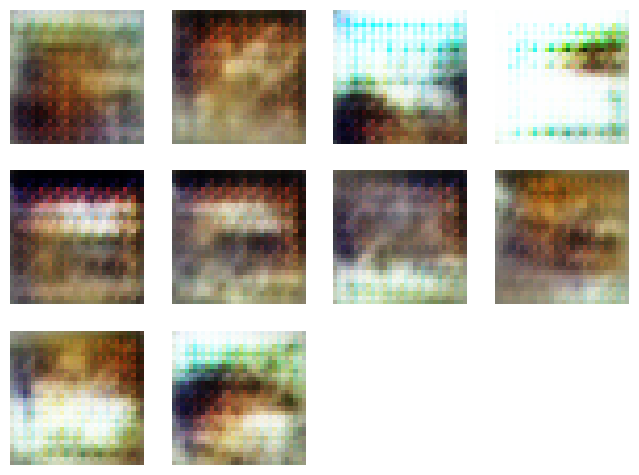

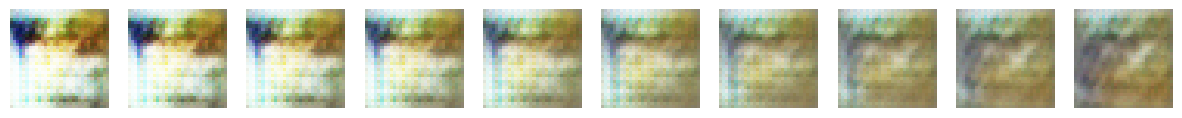

In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. DATA PREPARATION
# ==============================

# Load CIFAR-10 dataset
(x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()

# Normalize images between -1 and 1
x_train = (x_train.astype('float32') - 127.5) / 127.5

BUFFER_SIZE = 60000
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# Latent vector dimension
LATENT_DIM = 100


# ==============================
# 2. GENERATOR MODEL (DCGAN)
# ==============================

def build_generator():
    model = tf.keras.Sequential()

    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(LATENT_DIM,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((8, 8, 256)))

    model.add(layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(3, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh'))

    return model


# ==============================
# 3. DISCRIMINATOR MODEL
# ==============================

def build_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=[32,32,3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model


generator = build_generator()
discriminator = build_discriminator()


# ==============================
# 4. LOSS & OPTIMIZER
# ==============================

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)


# ==============================
# 5. TRAINING STEP
# ==============================

@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))


# ==============================
# 6. TRAINING LOOP
# ==============================

EPOCHS = 10

for epoch in range(EPOCHS):
    for image_batch in dataset:
        train_step(image_batch)

    print(f"Epoch {epoch+1} completed")


# ==============================
# 7. GENERATE ARTISTIC IMAGES
# ==============================

def generate_images():
    noise = tf.random.normal([10, LATENT_DIM])
    generated_images = generator(noise, training=False)

    plt.figure(figsize=(8,8))

    for i in range(10):
        plt.subplot(4,4,i+1)
        img = (generated_images[i] + 1) / 2
        plt.imshow(img)
        plt.axis('off')

    plt.show()

generate_images()


# ==============================
# 8. LATENT SPACE INTERPOLATION
# ==============================

def interpolate():
    z1 = tf.random.normal([1, LATENT_DIM])
    z2 = tf.random.normal([1, LATENT_DIM])

    steps = 10
    plt.figure(figsize=(15,3))

    for i, alpha in enumerate(np.linspace(0,1,steps)):
        z = (1-alpha)*z1 + alpha*z2
        img = generator(z, training=False)[0]
        img = (img + 1)/2

        plt.subplot(1,steps,i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.show()

interpolate()

Streaming output truncated to the last 5000 lines.
------------------------
--- train_step debug ---
real_x shape: [1 128 128 3]
fake_y shape: [1 128 128 3]
gen_g_loss: 0.779764473
disc_x_loss: 1.34694374
total_cycle_loss: 1.93170881
------------------------
--- train_step debug ---
real_x shape: [1 128 128 3]
fake_y shape: [1 128 128 3]
gen_g_loss: 0.70423007
disc_x_loss: 1.38968587
total_cycle_loss: 1.13511157
------------------------
--- train_step debug ---
real_x shape: [1 128 128 3]
fake_y shape: [1 128 128 3]
gen_g_loss: 0.702141821
disc_x_loss: 1.35688734
total_cycle_loss: 1.86492479
------------------------
--- train_step debug ---
real_x shape: [1 128 128 3]
fake_y shape: [1 128 128 3]
gen_g_loss: 0.712722361
disc_x_loss: 1.41687667
total_cycle_loss: 1.22222
------------------------
--- train_step debug ---
real_x shape: [1 128 128 3]
fake_y shape: [1 128 128 3]
gen_g_loss: 0.733818471
disc_x_loss: 1.36830711
total_cycle_loss: 1.60661817
------------------------
--- train_ste

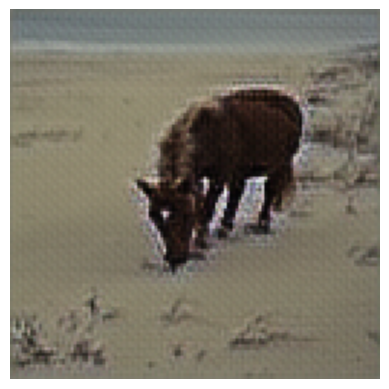

In [8]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt


dataset, metadata = tfds.load('cycle_gan/horse2zebra',
                             with_info=True,
                             as_supervised=True)

train_horses, train_zebras = dataset['trainA'], dataset['trainB']

IMG_SIZE = 128

def preprocess(image, label):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = (tf.cast(image, tf.float32) / 127.5) - 1
    return image

train_horses = train_horses.map(preprocess).batch(1)
train_zebras = train_zebras.map(preprocess).batch(1)


def build_generator():
    inputs = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3])

    x = tf.keras.layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2DTranspose(64, 4, strides=2, padding='same')(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='tanh')(x)

    return tf.keras.Model(inputs, x)


def build_discriminator():
    inputs = tf.keras.layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3])

    x = tf.keras.layers.Conv2D(64, 4, strides=2, padding='same')(inputs)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2D(1, 4, padding='same')(x)

    return tf.keras.Model(inputs, x)


G = build_generator()  # Horse → Zebra
F = build_generator()  # Zebra → Horse

DX = build_discriminator()
DY = build_discriminator()


loss_obj = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake):
    return loss_obj(tf.ones_like(fake), fake)

def discriminator_loss(real, fake):
    real_loss = loss_obj(tf.ones_like(real), real)
    fake_loss = loss_obj(tf.zeros_like(fake), fake)
    return real_loss + fake_loss

def cycle_loss(real, cycled):
    return tf.reduce_mean(tf.abs(real - cycled)) * 10


g_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
f_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
dx_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
dy_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)


@tf.function
def train_step(real_x, real_y):

    with tf.GradientTape(persistent=True) as tape:

        fake_y = G(real_x, training=True)
        cycled_x = F(fake_y, training=True)

        fake_x = F(real_y, training=True)
        cycled_y = G(fake_x, training=True)

        disc_real_x = DX(real_x, training=True)
        disc_fake_x = DX(fake_x, training=True)

        disc_real_y = DY(real_y, training=True)
        disc_fake_y = DY(fake_y, training=True)

        gen_g_loss = generator_loss(disc_fake_y)
        gen_f_loss = generator_loss(disc_fake_x)

        total_cycle_loss = cycle_loss(real_x, cycled_x) + cycle_loss(real_y, cycled_y)

        total_g_loss = gen_g_loss + total_cycle_loss
        total_f_loss = gen_f_loss + total_cycle_loss

        disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
        disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)

        tf.print('--- train_step debug ---')
        tf.print('real_x shape:', tf.shape(real_x))
        tf.print('fake_y shape:', tf.shape(fake_y))
        tf.print('gen_g_loss:', gen_g_loss)
        tf.print('disc_x_loss:', disc_x_loss)
        tf.print('total_cycle_loss:', total_cycle_loss)
        tf.print('------------------------')

    gradients_g = tape.gradient(total_g_loss, G.trainable_variables)
    gradients_f = tape.gradient(total_f_loss, F.trainable_variables)

    gradients_dx = tape.gradient(disc_x_loss, DX.trainable_variables)
    gradients_dy = tape.gradient(disc_y_loss, DY.trainable_variables)

    g_optimizer.apply_gradients(zip(gradients_g, G.trainable_variables))
    f_optimizer.apply_gradients(zip(gradients_f, F.trainable_variables))

    dx_optimizer.apply_gradients(zip(gradients_dx, DX.trainable_variables))
    dy_optimizer.apply_gradients(zip(gradients_dy, DY.trainable_variables))


EPOCHS = 5

for epoch in range(EPOCHS):
    for img_x, img_y in tf.data.Dataset.zip((train_horses, train_zebras)):
        train_step(img_x, img_y)

    print(f"Epoch {epoch+1} completed")


def show_image(model, image):
    pred = model(image, training=False)
    plt.imshow((pred[0] + 1) / 2)
    plt.axis('off')

for sample in train_horses.take(1):
    show_image(G, sample)
